Sección A — Setup, carga y visualización de la serie

In [2]:
# !pip install -q statsmodels pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# --- A.1 Carga e indexado temporal ---
df = pd.read_csv('cafe_seguro_master.csv', parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df = df.set_index('fecha')
df.index.freq = 'MS'

print('=== DATASET ===')
print(f'Periodo: {df.index.min().date()} → {df.index.max().date()}')
print(f'Shape:   {df.shape}')
print(f'\nPrimeras filas:')
print(df.head(3).round(2))

=== DATASET ===
Periodo: 2002-01-01 → 2025-12-01
Shape:   (288, 9)

Primeras filas:
            year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  \
fecha                                                                         
2002-01-01  2002      1                    84.60                      824.0   
2002-02-01  2002      2                    82.96                      808.0   
2002-03-01  2002      3                    79.88                      778.0   

            precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop  
fecha                                                                        
2002-01-01     118.09       0.80         0.82      0.89            276480.0  
2002-02-01     135.23       0.75         0.78      0.87            270960.0  
2002-03-01     234.07       0.68         0.73      0.85            296859.0  


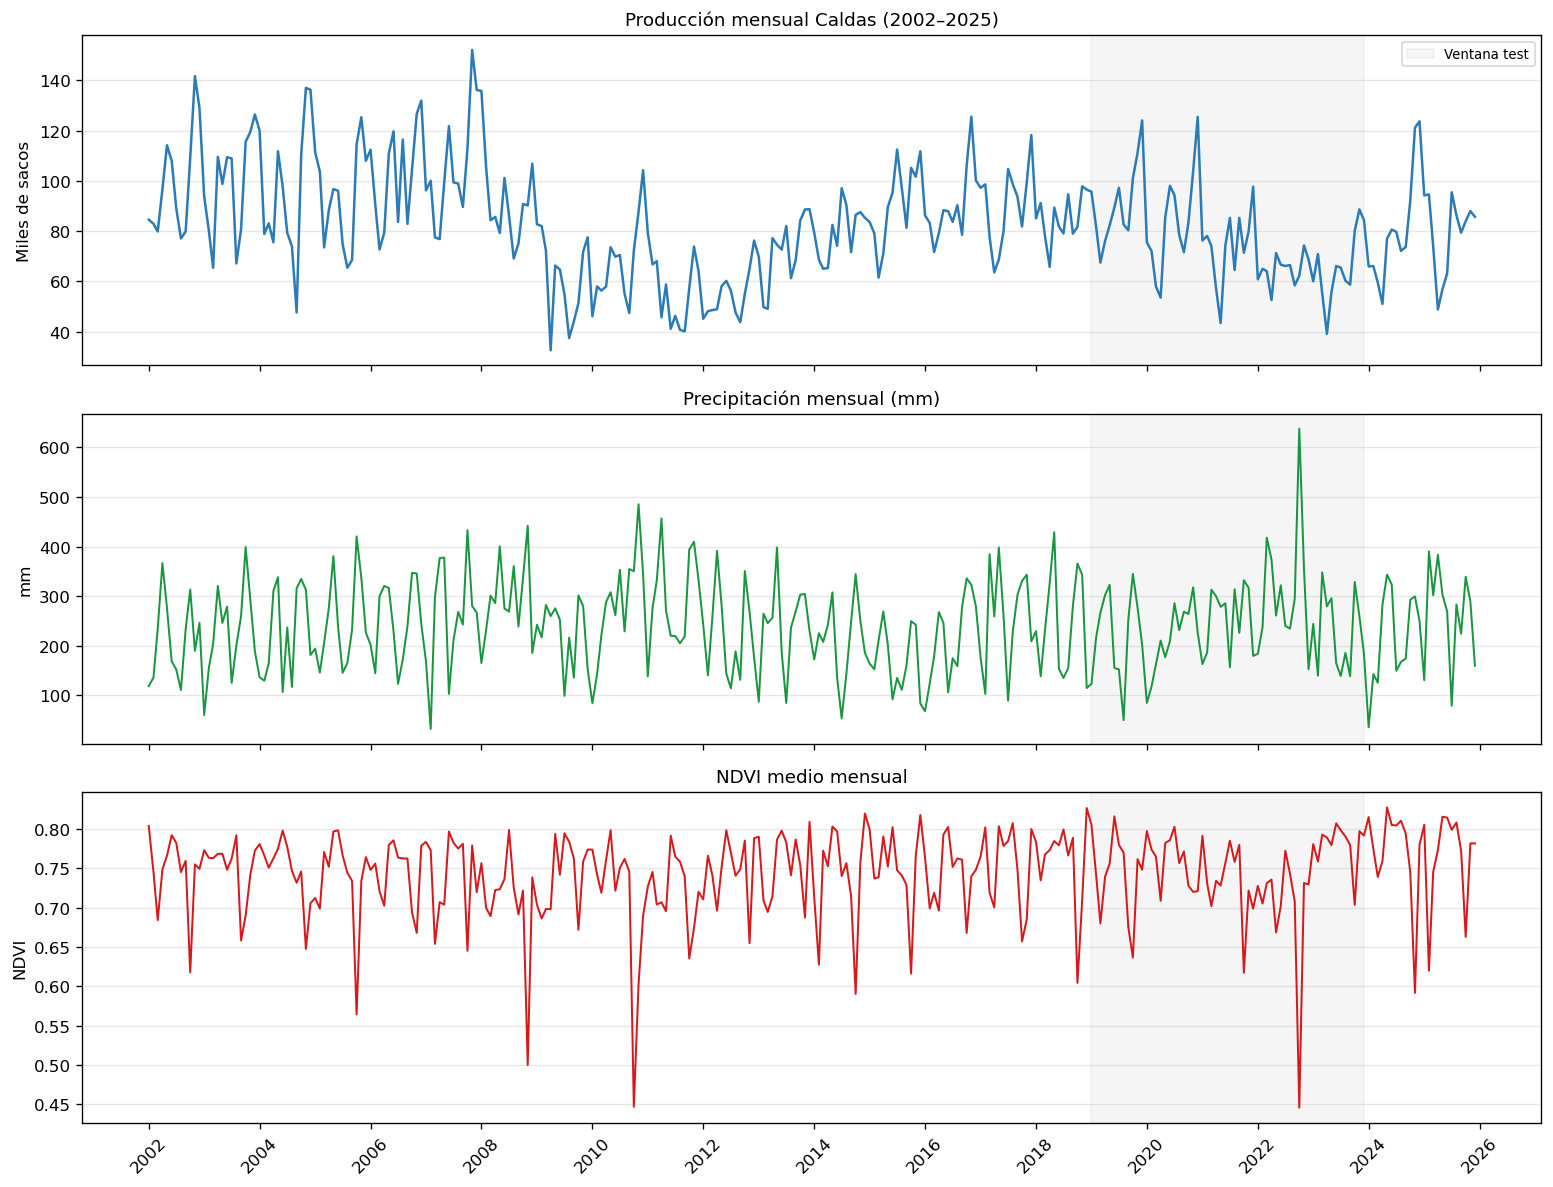

Gráfica guardada: sA_serie_temporal.png


In [4]:
# --- A.2 Visualización de la serie objetivo y covariables ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(df.index, df['prod_caldas_miles_sacos'], color='#2c7bb6', lw=1.5)
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray', label='Ventana test')
axes[0].set_ylabel('Miles de sacos')
axes[0].set_title('Producción mensual Caldas (2002–2025)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(df.index, df['precip_mm'], color='#1a9641', lw=1.2)
axes[1].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[1].set_ylabel('mm')
axes[1].set_title('Precipitación mensual (mm)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

axes[2].plot(df.index, df['ndvi_mean'], color='#d7191c', lw=1.2)
axes[2].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[2].set_ylabel('NDVI')
axes[2].set_title('NDVI medio mensual', fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sA_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sA_serie_temporal.png')

Sección B — Análisis de estacionariedad y diagnóstico de la serie

In [7]:
# --- B.1 Test de Dickey-Fuller aumentado (ADF) ---
# SARIMAX requiere que la serie sea estacionaria o indica si hay que diferenciar
TARGET = 'prod_caldas_miles_sacos'
serie = df[TARGET].copy()

resultado_adf = adfuller(serie.dropna(), autolag='AIC')
print('=== TEST ADF — PRODUCCIÓN CALDAS ===')
print(f'Estadístico ADF : {resultado_adf[0]:.4f}')
print(f'p-valor         : {resultado_adf[1]:.4f}')
print(f'Lags usados     : {resultado_adf[2]}')
print(f'Obs usadas      : {resultado_adf[3]}')
print('Valores críticos:')
for key, val in resultado_adf[4].items():
    print(f'  {key}: {val:.4f}')
if resultado_adf[1] < 0.05:
    print('\n→ Serie ESTACIONARIA (p < 0.05) — d=0 es candidato')
else:
    print('\n→ Serie NO estacionaria (p ≥ 0.05) — considerar d=1')

=== TEST ADF — PRODUCCIÓN CALDAS ===
Estadístico ADF : -2.1295
p-valor         : 0.2328
Lags usados     : 14
Obs usadas      : 273
Valores críticos:
  1%: -3.4545
  5%: -2.8722
  10%: -2.5724

→ Serie NO estacionaria (p ≥ 0.05) — considerar d=1


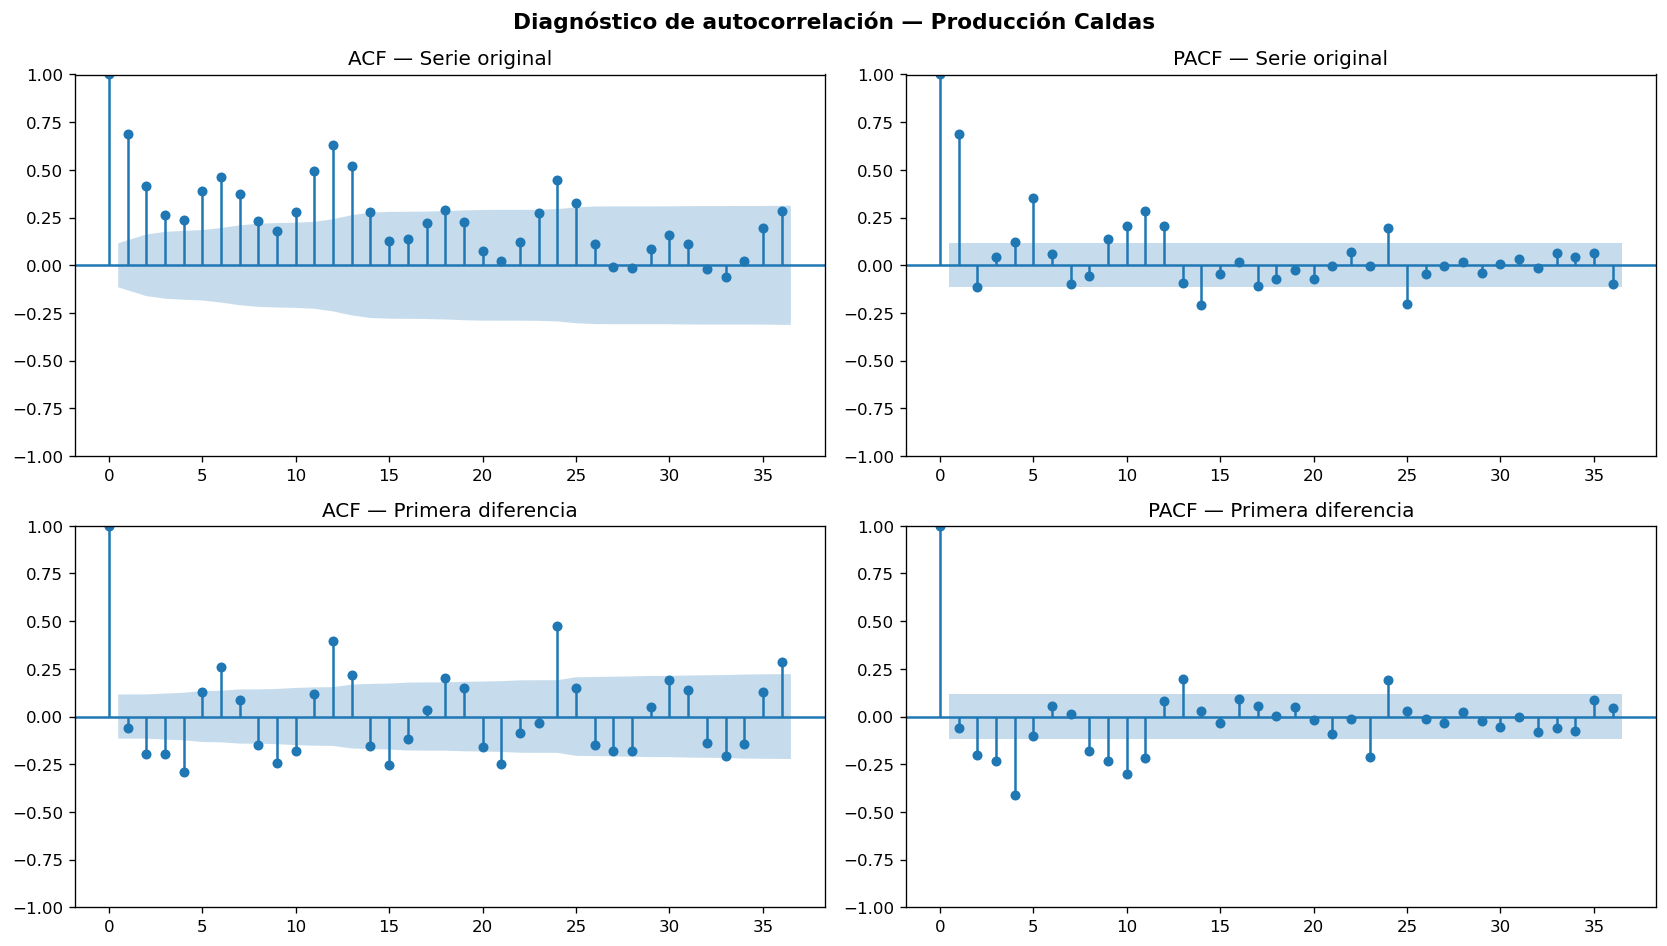

Gráfica guardada: sB_acf_pacf.png


In [9]:
# --- B.2 Gráficos ACF y PACF para identificar p, q ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF y PACF de la serie original
plot_acf(serie.dropna(),  lags=36, ax=axes[0, 0], title='ACF — Serie original')
plot_pacf(serie.dropna(), lags=36, ax=axes[0, 1], title='PACF — Serie original', method='ywm')

# ACF y PACF de la serie diferenciada (por si se necesita d=1)
serie_diff = serie.diff().dropna()
plot_acf(serie_diff,  lags=36, ax=axes[1, 0], title='ACF — Primera diferencia')
plot_pacf(serie_diff, lags=36, ax=axes[1, 1], title='PACF — Primera diferencia', method='ywm')

plt.suptitle('Diagnóstico de autocorrelación — Producción Caldas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sB_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sB_acf_pacf.png')

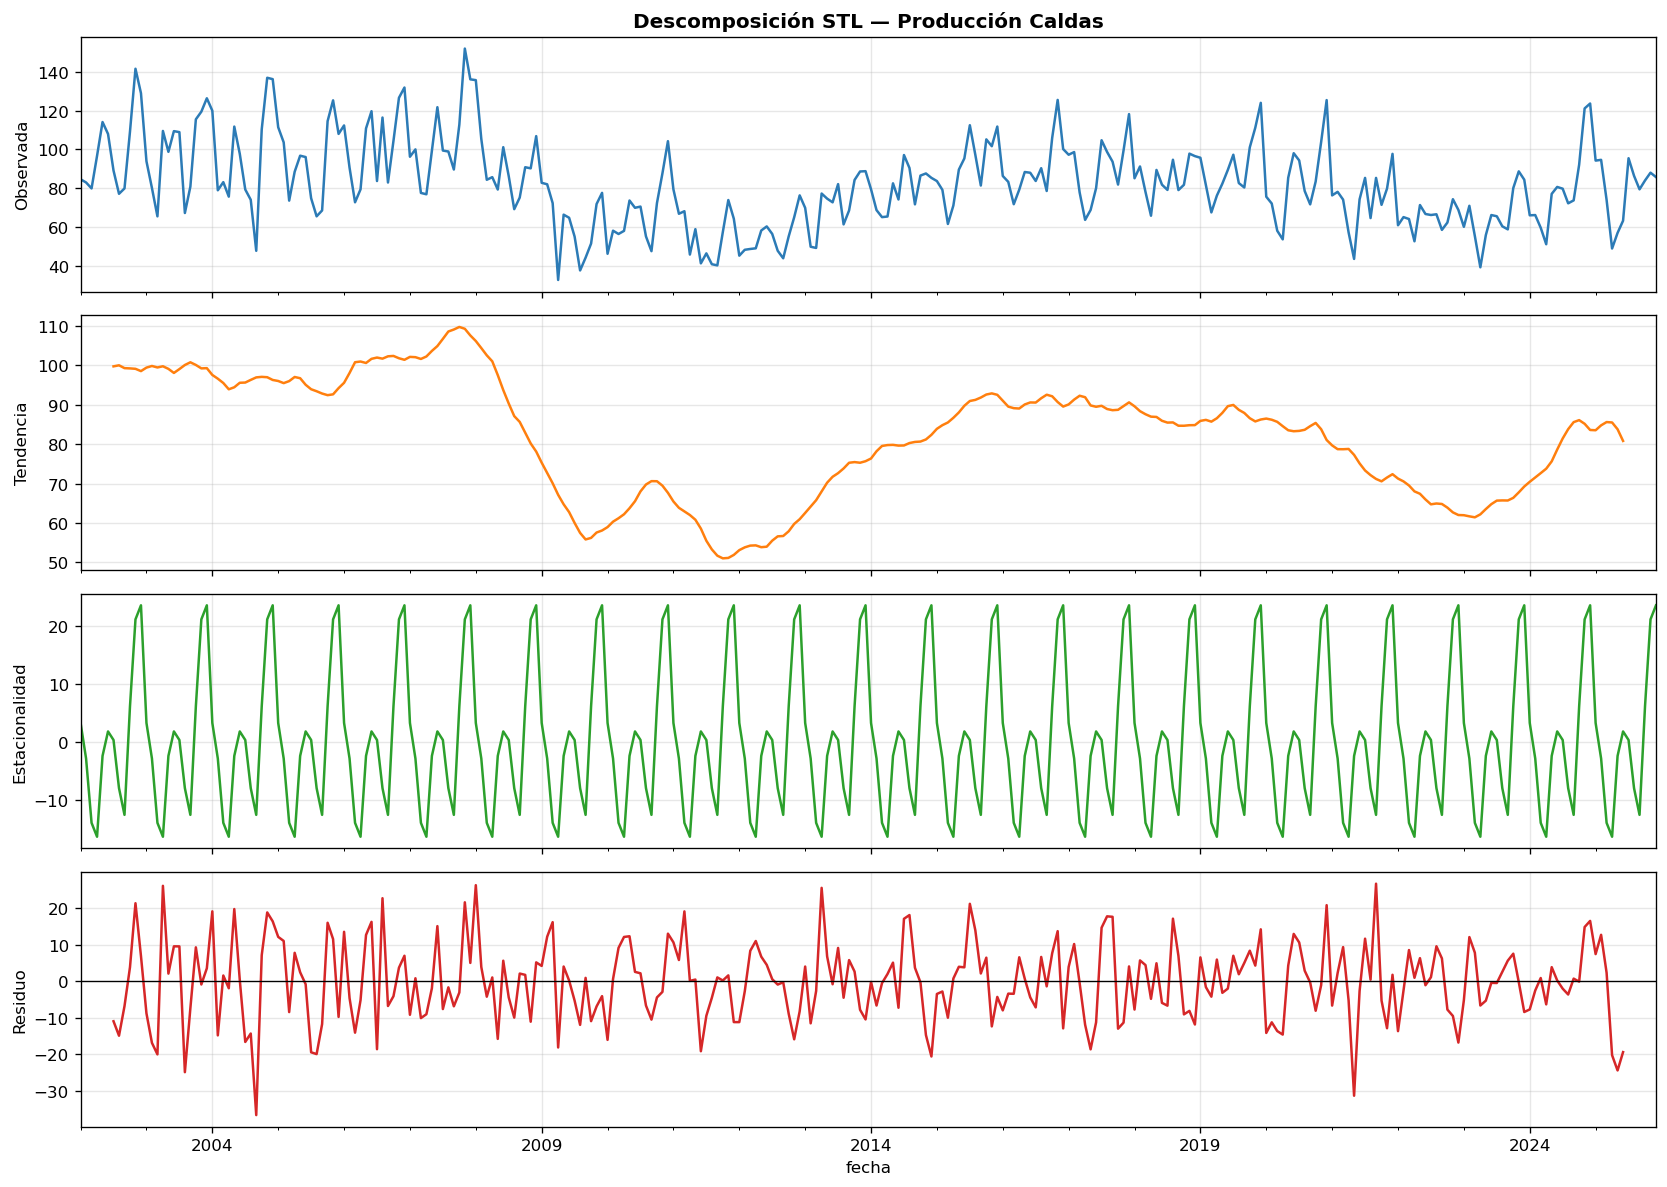

Gráfica guardada: sB_descomposicion.png


In [11]:
# --- B.3 Descomposición estacional para confirmar período S=12 ---
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(serie, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='#2c7bb6')
axes[0].set_ylabel('Observada')
axes[0].set_title('Descomposición STL — Producción Caldas', fontweight='bold')
decomp.trend.plot(ax=axes[1], color='#ff7f0e')
axes[1].set_ylabel('Tendencia')
decomp.seasonal.plot(ax=axes[2], color='#2ca02c')
axes[2].set_ylabel('Estacionalidad')
decomp.resid.plot(ax=axes[3], color='#d62728')
axes[3].set_ylabel('Residuo')
axes[3].axhline(0, color='black', lw=0.8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sB_descomposicion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sB_descomposicion.png')

Sección C — Partición train / test / demo

In [13]:
# --- C.1 Partición temporal ---
# Train: 2002-01 a 2018-12  (204 meses)
# Test:  2019-01 a 2023-12  (60 meses, out-of-sample)
# Demo:  2024-01 a 2025-12  (reservado para artefacto)

df_reset = df.reset_index()

train = df[df.index <= '2018-12-01'].copy()
test  = df[(df.index >= '2019-01-01') & (df.index <= '2023-12-01')].copy()
demo  = df[df.index >= '2024-01-01'].copy()

print('=== PARTICIÓN WALK-FORWARD ===')
print(f'Train: {train.index.min().date()} → {train.index.max().date()} | {len(train)} meses')
print(f'Test:  {test.index.min().date()}  → {test.index.max().date()}  | {len(test)} meses')
print(f'Demo:  {demo.index.min().date()}  → {demo.index.max().date()}  | {len(demo)} meses')
print(f'Total: {len(train)+len(test)+len(demo)} meses')

=== PARTICIÓN WALK-FORWARD ===
Train: 2002-01-01 → 2018-12-01 | 204 meses
Test:  2019-01-01  → 2023-12-01  | 60 meses
Demo:  2024-01-01  → 2025-12-01  | 24 meses
Total: 288 meses


In [15]:
# --- C.2 Preparación de covariables exógenas ---
# Se usan como variables exógenas: precipitación rezago 3 y NDVI rezago 3
# (rezagos cortos para que las covariables sean disponibles al momento de predecir)
EXOG_COLS = ['precip_mm', 'ndvi_mean']

exog_train = train[EXOG_COLS].copy()
exog_test  = test[EXOG_COLS].copy()
exog_demo  = demo[EXOG_COLS].copy()

y_train = train[TARGET]
y_test  = test[TARGET]
y_demo  = demo[TARGET]

print('=== COVARIABLES EXÓGENAS ===')
print(f'Variables: {EXOG_COLS}')
print(f'X_train shape: {exog_train.shape}')
print(f'X_test  shape: {exog_test.shape}')
print(exog_train.describe().round(2))

=== COVARIABLES EXÓGENAS ===
Variables: ['precip_mm', 'ndvi_mean']
X_train shape: (204, 2)
X_test  shape: (60, 2)
       precip_mm  ndvi_mean
count     204.00     204.00
mean      238.56       0.74
std        91.84       0.05
min        31.47       0.45
25%       164.44       0.71
50%       240.51       0.75
75%       302.61       0.78
max       485.26       0.83


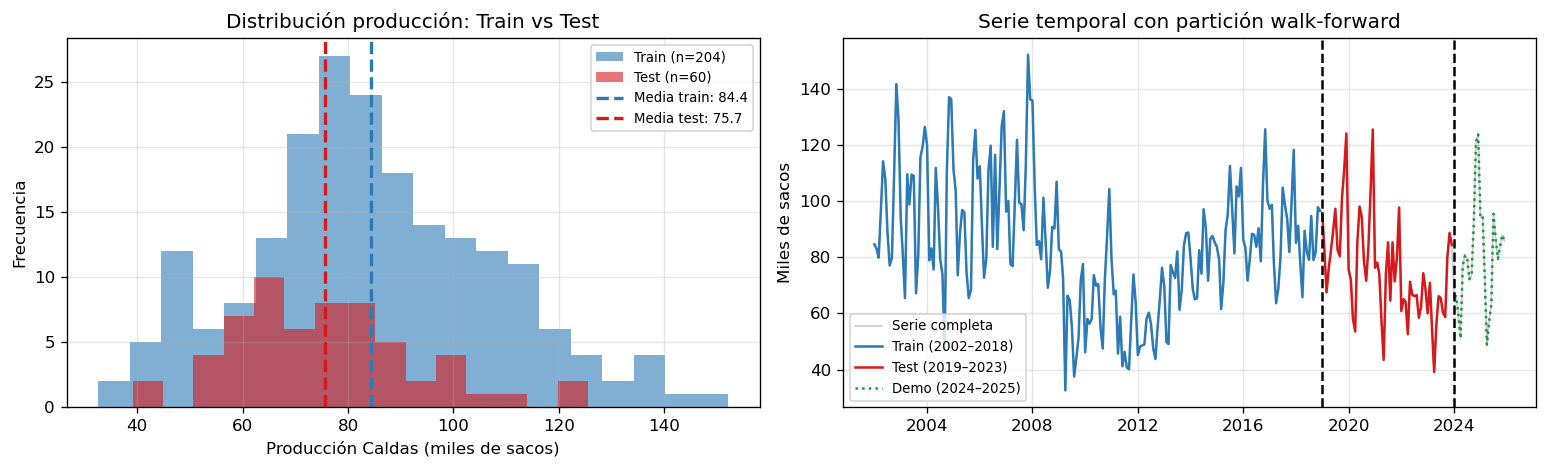

Gráfica guardada: sC_particion_train_test.png

=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===
       Train (2002–2018)  Test  (2019–2023)
count             204.00              60.00
mean               84.41              75.65
std                23.06              17.50
min                32.60              39.14
25%                69.67              64.44
50%                82.64              74.16
75%                98.83              84.62
max               152.11             125.50


In [17]:
# --- C.3 Verificación distribución train vs test ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train, bins=20, alpha=0.6, color='#2c7bb6', label=f'Train (n={len(y_train)})')
axes[0].hist(y_test,  bins=15, alpha=0.6, color='#d7191c', label=f'Test (n={len(y_test)})')
axes[0].axvline(y_train.mean(), color='#2c7bb6', lw=2, linestyle='--',
                label=f'Media train: {y_train.mean():.1f}')
axes[0].axvline(y_test.mean(),  color='#d7191c', lw=2, linestyle='--',
                label=f'Media test: {y_test.mean():.1f}')
axes[0].set_xlabel('Producción Caldas (miles de sacos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución producción: Train vs Test')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df[TARGET], color='gray', lw=1, alpha=0.4, label='Serie completa')
axes[1].plot(train.index, y_train, color='#2c7bb6', lw=1.5, label='Train (2002–2018)')
axes[1].plot(test.index,  y_test,  color='#d7191c', lw=1.5, label='Test (2019–2023)')
axes[1].plot(demo.index,  y_demo,  color='#1a9641', lw=1.5, linestyle=':', label='Demo (2024–2025)')
axes[1].axvline(pd.Timestamp('2019-01-01'), color='black', lw=1.5, linestyle='--')
axes[1].axvline(pd.Timestamp('2024-01-01'), color='black', lw=1.5, linestyle='--')
axes[1].set_ylabel('Miles de sacos')
axes[1].set_title('Serie temporal con partición walk-forward')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sC_particion_train_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sC_particion_train_test.png')

print('\n=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===')
comp = pd.DataFrame({
    'Train (2002–2018)': y_train.describe(),
    'Test  (2019–2023)': y_test.describe()
}).round(2)
print(comp.to_string())

Sección D — Entrenamiento de modelos SARIMAX

In [19]:
# --- D.1 Función auxiliar de métricas ---
def calcular_metricas(y_real, y_pred, nombre, split):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    ss_res = np.sum((np.array(y_real) - np.array(y_pred)) ** 2)
    ss_tot = np.sum((np.array(y_real) - np.array(y_real).mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {
        'modelo': nombre, 'split': split,
        'RMSE': round(rmse, 3),
        'MAPE': round(mape, 3),
        'R2':   round(r2, 3)
    }

print('Función de métricas definida.')

Función de métricas definida.


In [21]:
# --- D.2 Definición de especificaciones SARIMAX ---
# Cuatro especificaciones de complejidad creciente
# Notación SARIMAX: (p,d,q)(P,D,Q,S)
# p/q: AR/MA no estacional | d: diferenciación
# P/Q: AR/MA estacional    | D: diferenciación estacional | S: período (12 meses)

ESPECIFICACIONES = {
    'M1_sarima_base':     {'order': (1,0,1), 'seasonal_order': (1,1,0,12), 'exog': False},
    'M2_sarima_seasonal': {'order': (1,0,1), 'seasonal_order': (1,1,1,12), 'exog': False},
    'M3_sarimax_precip':  {'order': (1,0,1), 'seasonal_order': (1,1,1,12), 'exog': True,  'cols': ['precip_mm']},
    'M4_sarimax_completo':{'order': (1,0,1), 'seasonal_order': (1,1,1,12), 'exog': True,  'cols': ['precip_mm', 'ndvi_mean']},
}

print('=== ESPECIFICACIONES SARIMAX ===')
for nombre, spec in ESPECIFICACIONES.items():
    exog_info = spec.get('cols', 'ninguna')
    print(f"{nombre}:")
    print(f"  order={spec['order']} | seasonal_order={spec['seasonal_order']}")
    print(f"  Variables exógenas: {exog_info}")

=== ESPECIFICACIONES SARIMAX ===
M1_sarima_base:
  order=(1, 0, 1) | seasonal_order=(1, 1, 0, 12)
  Variables exógenas: ninguna
M2_sarima_seasonal:
  order=(1, 0, 1) | seasonal_order=(1, 1, 1, 12)
  Variables exógenas: ninguna
M3_sarimax_precip:
  order=(1, 0, 1) | seasonal_order=(1, 1, 1, 12)
  Variables exógenas: ['precip_mm']
M4_sarimax_completo:
  order=(1, 0, 1) | seasonal_order=(1, 1, 1, 12)
  Variables exógenas: ['precip_mm', 'ndvi_mean']


In [23]:
# --- D.3 Entrenamiento y predicción de los 4 modelos ---
resultados = {}
metricas_todas = []

for nombre, spec in ESPECIFICACIONES.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {nombre}")
    print(f"{'='*60}")

    # Definir exógenas si aplica
    exog_tr = train[spec['cols']] if spec['exog'] else None
    exog_te = test[spec['cols']]  if spec['exog'] else None

    # Ajuste del modelo
    modelo = SARIMAX(
        y_train,
        exog=exog_tr,
        order=spec['order'],
        seasonal_order=spec['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    print(f'AIC: {modelo.aic:.2f} | BIC: {modelo.bic:.2f}')
    print(modelo.summary().tables[1])

    # Predicción in-sample (train)
    pred_train = modelo.fittedvalues

    # Predicción out-of-sample (test) — forecast paso a paso
    forecast_test = modelo.forecast(steps=len(y_test), exog=exog_te)

    # Guardar resultados
    resultados[nombre] = {
        'modelo':        modelo,
        'pred_train':    pred_train,
        'pred_test':     forecast_test,
        'spec':          spec
    }

    # Calcular métricas
    metricas_todas.append(calcular_metricas(y_train, pred_train,    nombre, 'train'))
    metricas_todas.append(calcular_metricas(y_test,  forecast_test, nombre, 'test'))


MODELO: M1_sarima_base
AIC: 1440.99 | BIC: 1453.74
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8912      0.040     22.339      0.000       0.813       0.969
ma.L1         -0.4225      0.096     -4.398      0.000      -0.611      -0.234
ar.S.L12      -0.5542      0.065     -8.546      0.000      -0.681      -0.427
sigma2       175.3755     16.361     10.719      0.000     143.308     207.443

MODELO: M2_sarima_seasonal
AIC: 1428.35 | BIC: 1444.26
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9201      0.036     25.452      0.000       0.849       0.991
ma.L1         -0.4697      0.092     -5.120      0.000      -0.649      -0.290
ar.S.L12      -0.3948      0.107     -3.683      0.000      -0.605      -0.185
ma.S.L12      -0.2802  

In [25]:
# --- D.4 Tabla comparativa de métricas ---
df_metricas = pd.DataFrame(metricas_todas)
tabla = df_metricas.pivot(index='modelo', columns='split', values=['RMSE','MAPE','R2'])
tabla.columns = ['_'.join(col).strip() for col in tabla.columns]
tabla = tabla[['RMSE_train','RMSE_test','MAPE_train','MAPE_test','R2_train','R2_test']]

print('\n' + '='*70)
print('TABLA COMPARATIVA — 4 MODELOS SARIMAX')
print('='*70)
print(tabla.to_string())

# Mejor modelo en test por RMSE
mejor = tabla['RMSE_test'].idxmin()
print(f'\n→ Mejor modelo en test (RMSE): {mejor}')
print(f'  RMSE test : {tabla.loc[mejor,"RMSE_test"]}')
print(f'  MAPE test : {tabla.loc[mejor,"MAPE_test"]}%')
print(f'  R²   test : {tabla.loc[mejor,"R2_test"]}')


TABLA COMPARATIVA — 4 MODELOS SARIMAX
                     RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
modelo                                                                              
M1_sarima_base           17.252     15.719      14.992     19.253     0.438    0.180
M2_sarima_seasonal       16.872     15.660      14.761     19.287     0.462    0.186
M3_sarimax_precip        17.201     15.543      14.891     18.778     0.441    0.198
M4_sarimax_completo      16.901     15.488      14.844     18.668     0.460    0.203

→ Mejor modelo en test (RMSE): M4_sarimax_completo
  RMSE test : 15.488
  MAPE test : 18.668%
  R²   test : 0.203


Sección E — Visualización de predicciones

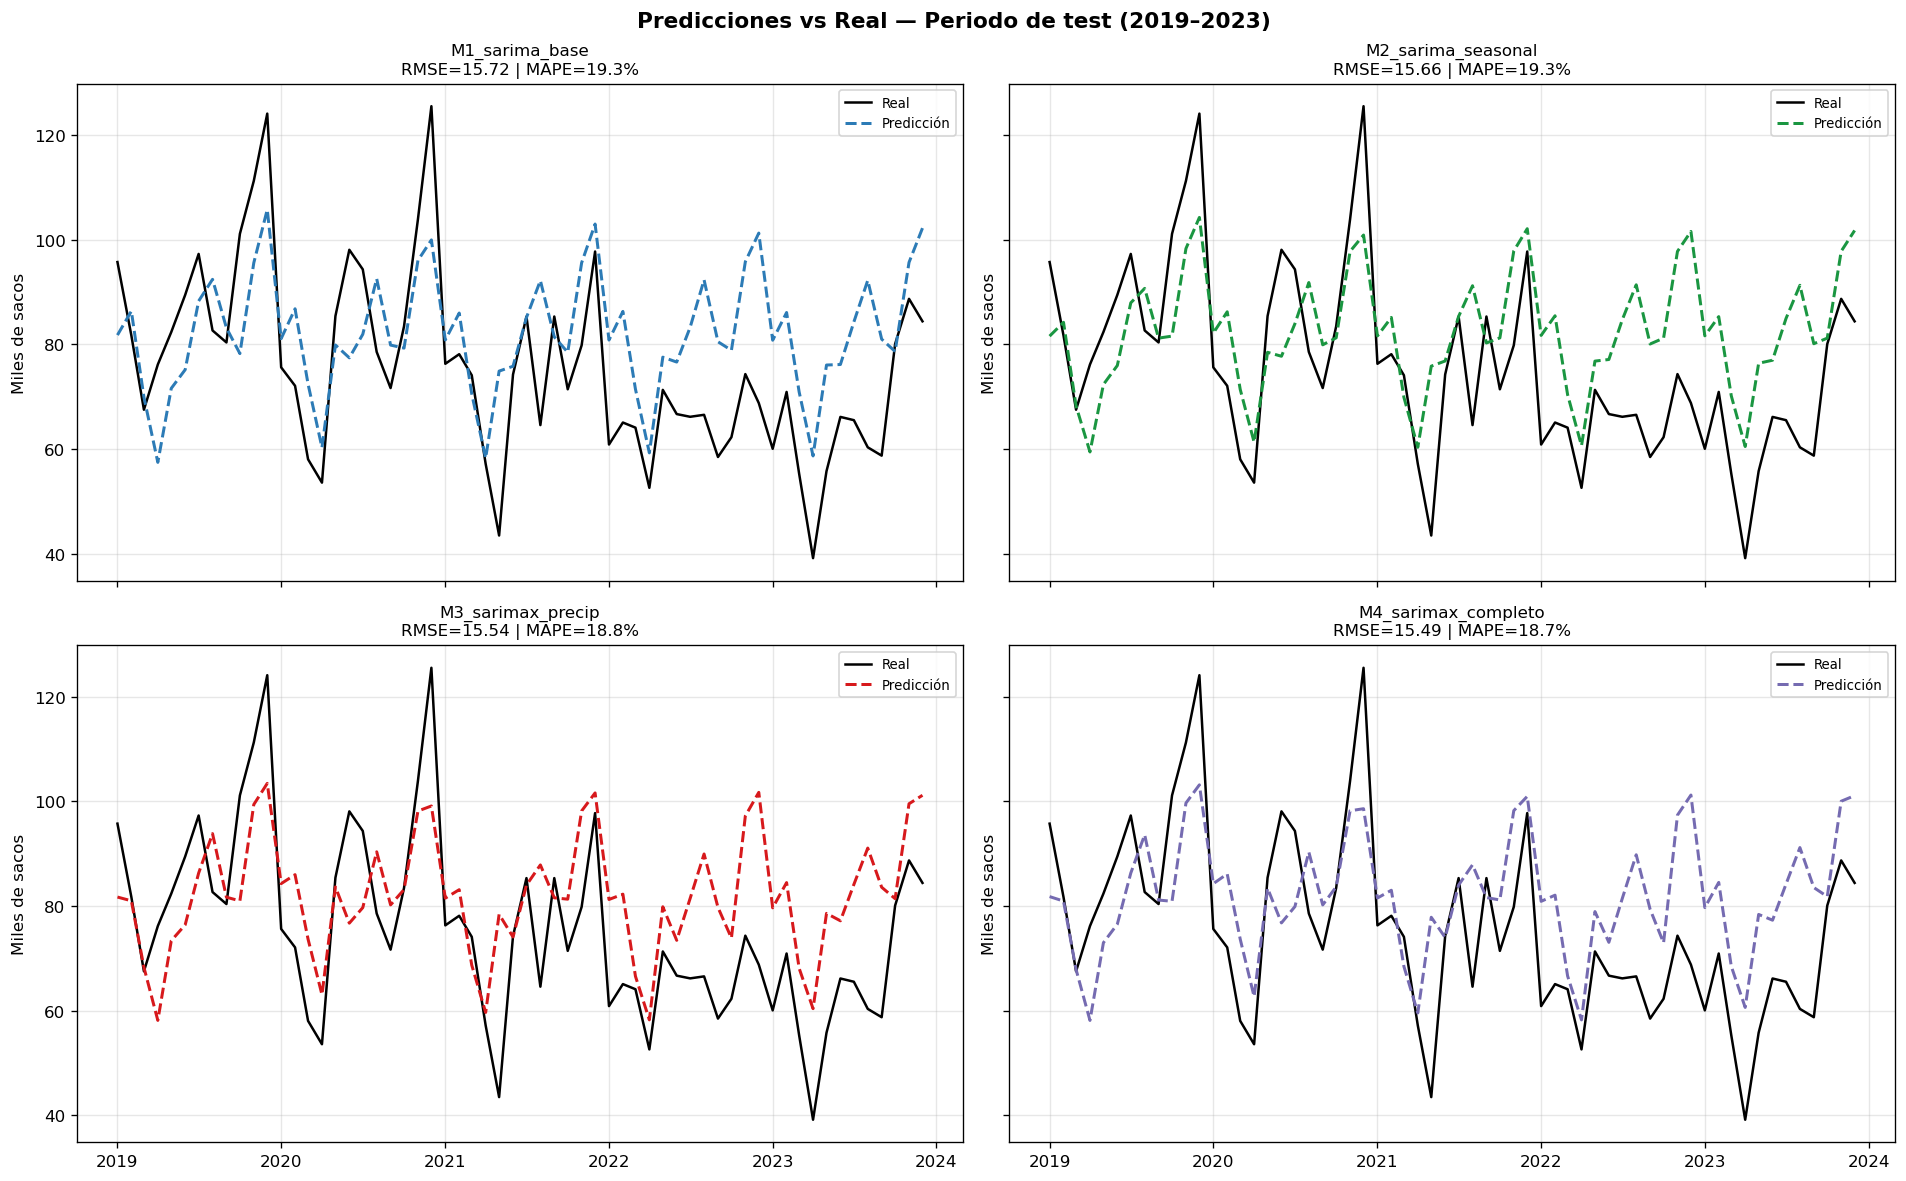

Gráfica guardada: sE_predicciones_test.png


In [28]:
# --- E.1 Predicciones vs valores reales en periodo de test ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

colores = ['#2c7bb6', '#1a9641', '#d7191c', '#756bb1']

for i, (nombre, res) in enumerate(resultados.items()):
    ax = axes[i]

    # Real vs predicho en test
    ax.plot(y_test.index, y_test.values, color='black', lw=1.5, label='Real', zorder=3)
    ax.plot(y_test.index, res['pred_test'].values, color=colores[i],
            lw=1.8, linestyle='--', label='Predicción', zorder=3)

    # Métricas en el gráfico
    rmse_te = np.sqrt(mean_squared_error(y_test, res['pred_test']))
    mape_te = mean_absolute_percentage_error(y_test, res['pred_test']) * 100
    ax.set_title(f'{nombre}\nRMSE={rmse_te:.2f} | MAPE={mape_te:.1f}%', fontsize=10)
    ax.set_ylabel('Miles de sacos')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Predicciones vs Real — Periodo de test (2019–2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sE_predicciones_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sE_predicciones_test.png')

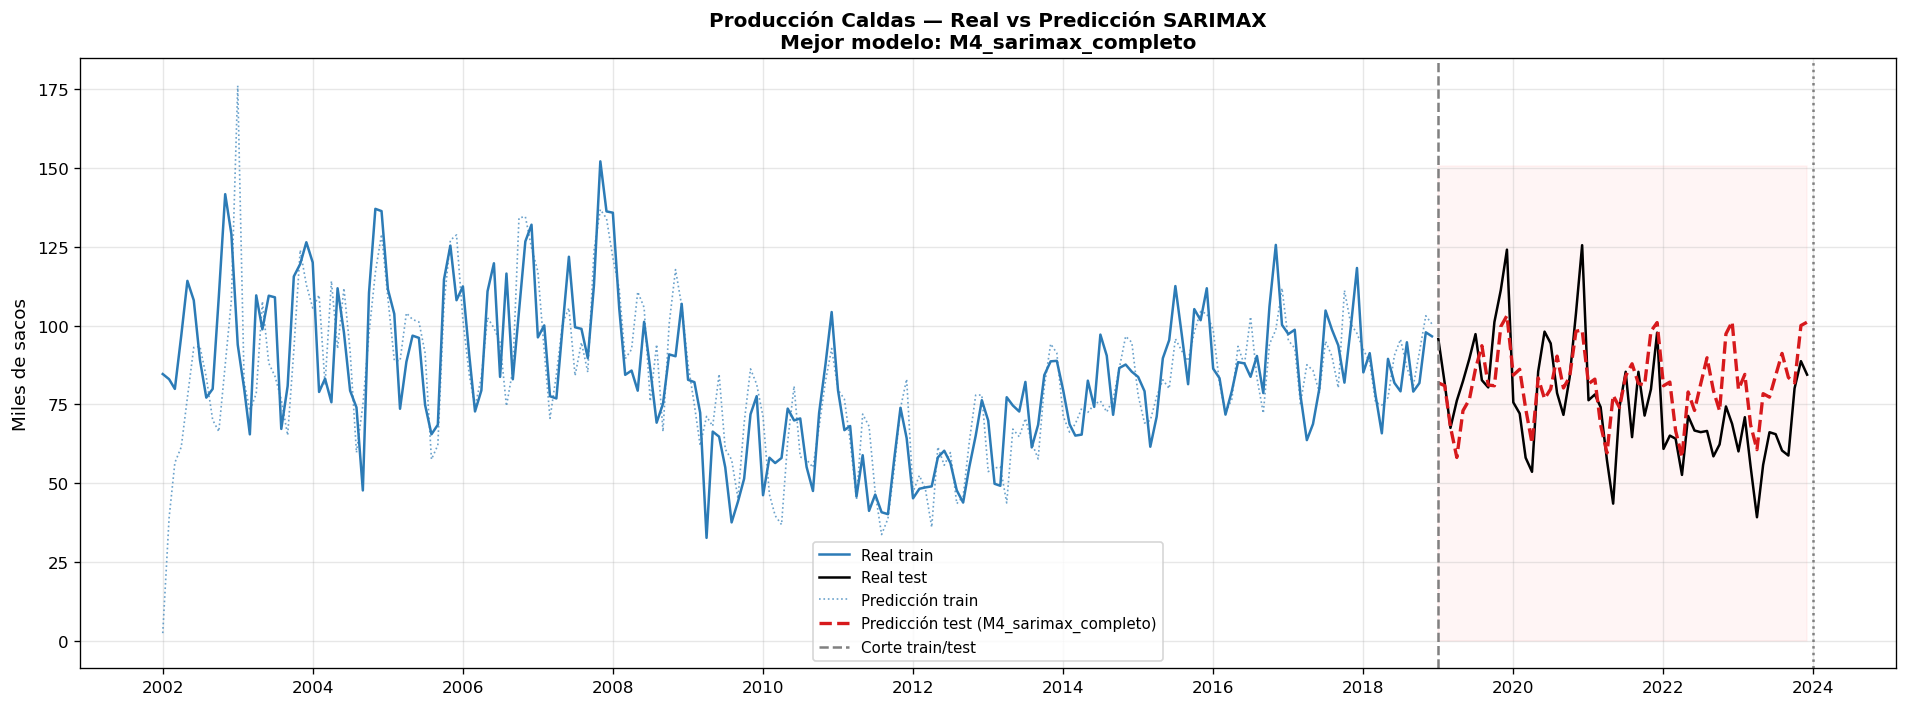

Gráfica guardada: sE_serie_completa_mejor_modelo.png


In [30]:
# --- E.2 Serie completa: train + test + predicción del mejor modelo ---
mejor_modelo = resultados[mejor]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(y_train.index, y_train.values, color='#2c7bb6', lw=1.5, label='Real train')
ax.plot(y_test.index,  y_test.values,  color='black',   lw=1.5, label='Real test')
ax.plot(y_train.index, mejor_modelo['pred_train'].values,
        color='#2c7bb6', lw=1, linestyle=':', alpha=0.7, label='Predicción train')
ax.plot(y_test.index, mejor_modelo['pred_test'].values,
        color='#d7191c', lw=2, linestyle='--', label=f'Predicción test ({mejor})')

ax.axvline(pd.Timestamp('2019-01-01'), color='gray', lw=1.5, linestyle='--', label='Corte train/test')
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', lw=1.5, linestyle=':')
ax.fill_between(y_test.index, 0, y_test.max() * 1.2, alpha=0.04, color='red')

ax.set_ylabel('Miles de sacos', fontsize=11)
ax.set_title(f'Producción Caldas — Real vs Predicción SARIMAX\nMejor modelo: {mejor}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig('sE_serie_completa_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfica guardada: sE_serie_completa_mejor_modelo.png')

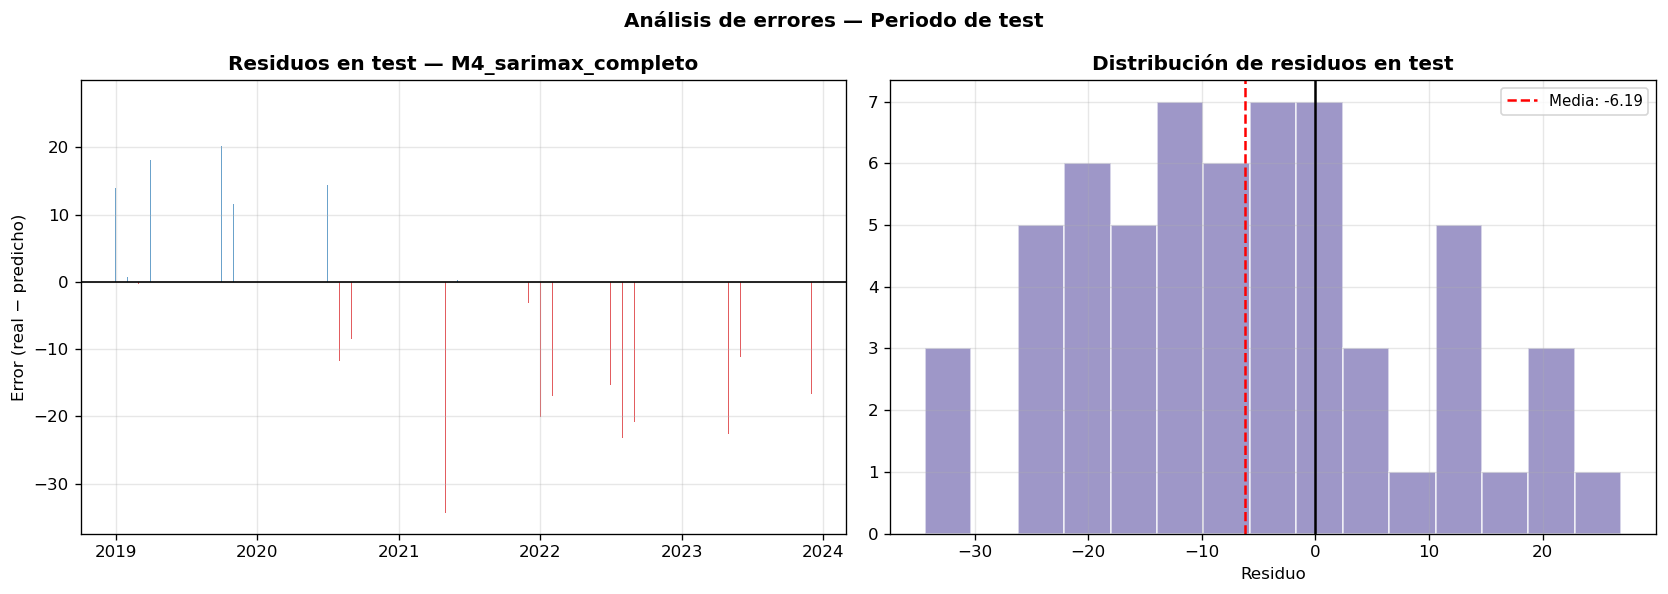

Gráfica guardada: sE_residuos_test.png


In [32]:
# --- E.3 Gráfico de errores (residuos) en test ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuos = y_test.values - mejor_modelo['pred_test'].values

axes[0].bar(y_test.index, residuos, color=[
    '#d7191c' if r < 0 else '#2c7bb6' for r in residuos], alpha=0.7)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylabel('Error (real − predicho)')
axes[0].set_title(f'Residuos en test — {mejor}', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].hist(residuos, bins=15, color='#756bb1', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].axvline(np.mean(residuos), color='red', lw=1.5, linestyle='--',
                label=f'Media: {np.mean(residuos):.2f}')
axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribución de residuos en test', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de errores — Periodo de test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sE_residuos_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sE_residuos_test.png')

Sección F — Diagnóstico del mejor modelo

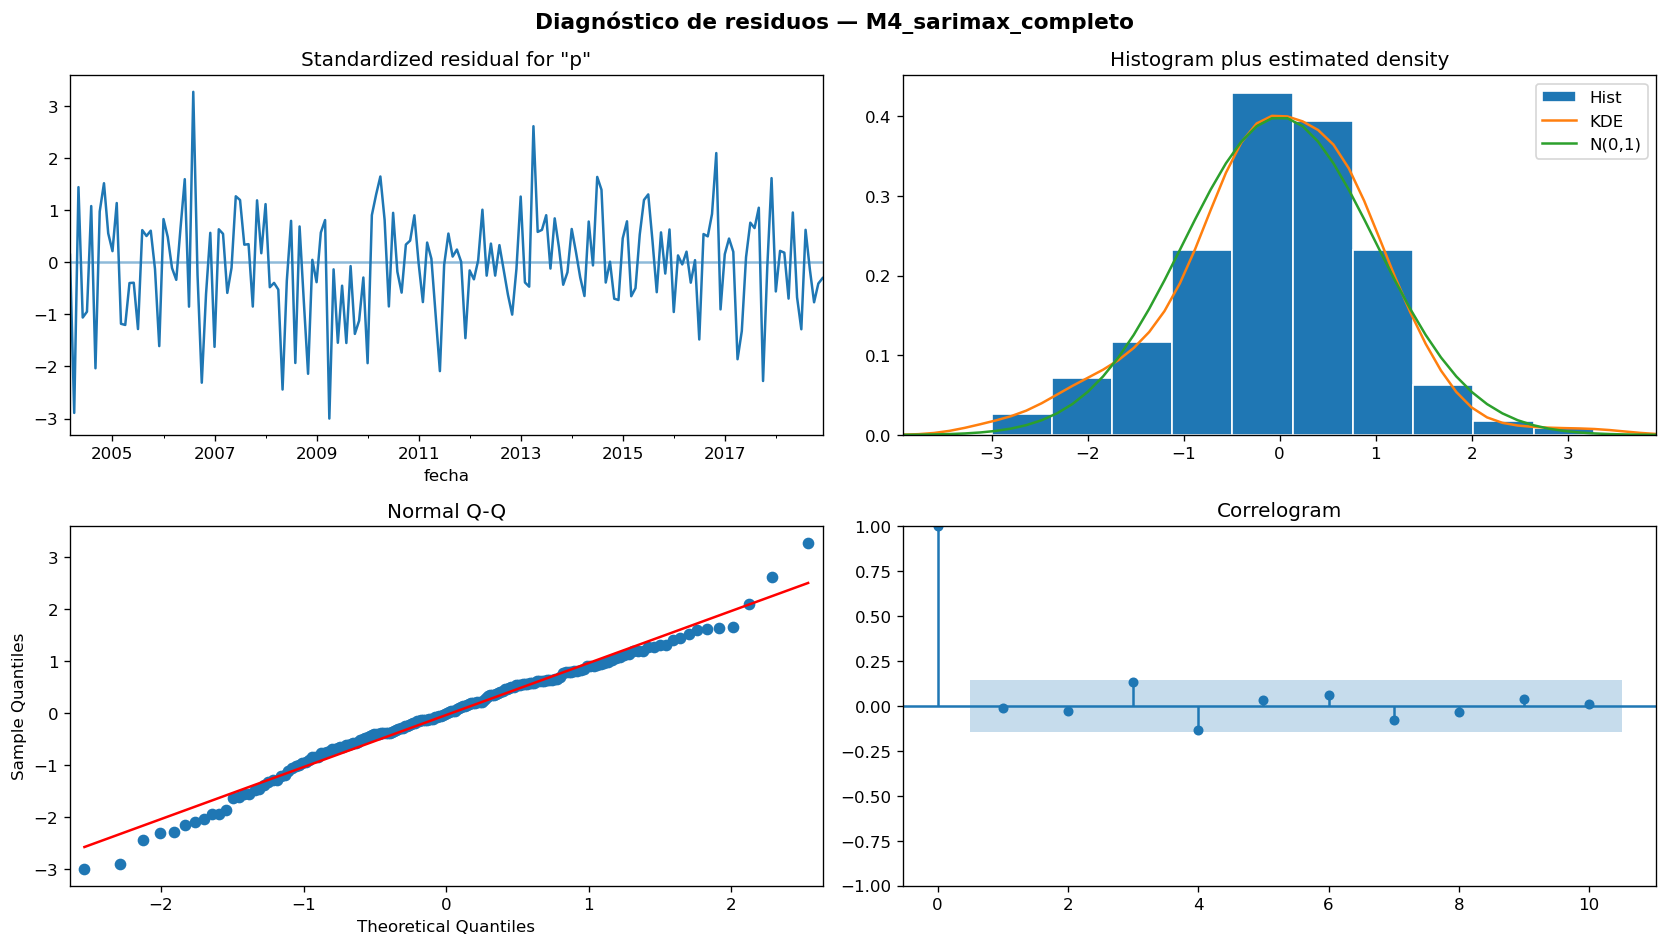

Gráfica guardada: sF_diagnostico_modelo.png


In [35]:
# --- F.1 Diagnóstico de residuos del modelo (plots de statsmodels) ---
mejor_modelo['modelo'].plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de residuos — {mejor}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sF_diagnostico_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: sF_diagnostico_modelo.png')

In [37]:
# --- F.2 Resumen comparativo final ---
print('\n' + '='*70)
print('RESUMEN FINAL — COMPARATIVA DE MODELOS SARIMAX')
print('='*70)
print(tabla.round(3).to_string())

print('\n=== INTERPRETACIÓN ===')
print(f'Mejor modelo en test (menor RMSE): {mejor}')
print(f'  RMSE test : {tabla.loc[mejor,"RMSE_test"]:.3f} miles de sacos')
print(f'  MAPE test : {tabla.loc[mejor,"MAPE_test"]:.2f}%')
print(f'  R²   test : {tabla.loc[mejor,"R2_test"]:.3f}')
print(f'\nSignificado del MAPE:')
mape_val = tabla.loc[mejor,'MAPE_test']
if mape_val < 10:
    print('  MAPE < 10% → predicción de alta precisión')
elif mape_val < 20:
    print('  MAPE entre 10% y 20% → predicción buena para series agrícolas')
else:
    print('  MAPE > 20% → predicción moderada — revisar especificación del modelo')


RESUMEN FINAL — COMPARATIVA DE MODELOS SARIMAX
                     RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
modelo                                                                              
M1_sarima_base           17.252     15.719      14.992     19.253     0.438    0.180
M2_sarima_seasonal       16.872     15.660      14.761     19.287     0.462    0.186
M3_sarimax_precip        17.201     15.543      14.891     18.778     0.441    0.198
M4_sarimax_completo      16.901     15.488      14.844     18.668     0.460    0.203

=== INTERPRETACIÓN ===
Mejor modelo en test (menor RMSE): M4_sarimax_completo
  RMSE test : 15.488 miles de sacos
  MAPE test : 18.67%
  R²   test : 0.203

Significado del MAPE:
  MAPE entre 10% y 20% → predicción buena para series agrícolas
